In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load dataset (dataset ini dipisahkan oleh titik koma, bukan koma)
df = pd.read_csv('../dataset/raw/student-por.csv', sep=';')

# Menampilkan 5 baris pertama untuk memastikan data terbaca dengan benar
display(df.head())

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [4]:
print(f"Jumlah baris dan kolom: {df.shape}")
print("\n--- Informasi Tipe Data ---")
df.info()

print("\n--- Pengecekan Missing Values ---")
print(df.isnull().sum().sum(), "Missing Values ditemukan.")

# Mengecek duplikasi data
print(f"Jumlah baris duplikat: {df.duplicated().sum()}")

Jumlah baris dan kolom: (649, 33)

--- Informasi Tipe Data ---
<class 'pandas.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      649 non-null    str  
 1   sex         649 non-null    str  
 2   age         649 non-null    int64
 3   address     649 non-null    str  
 4   famsize     649 non-null    str  
 5   Pstatus     649 non-null    str  
 6   Medu        649 non-null    int64
 7   Fedu        649 non-null    int64
 8   Mjob        649 non-null    str  
 9   Fjob        649 non-null    str  
 10  reason      649 non-null    str  
 11  guardian    649 non-null    str  
 12  traveltime  649 non-null    int64
 13  studytime   649 non-null    int64
 14  failures    649 non-null    int64
 15  schoolsup   649 non-null    str  
 16  famsup      649 non-null    str  
 17  paid        649 non-null    str  
 18  activities  649 non-null    str  
 19  nursery     649 non

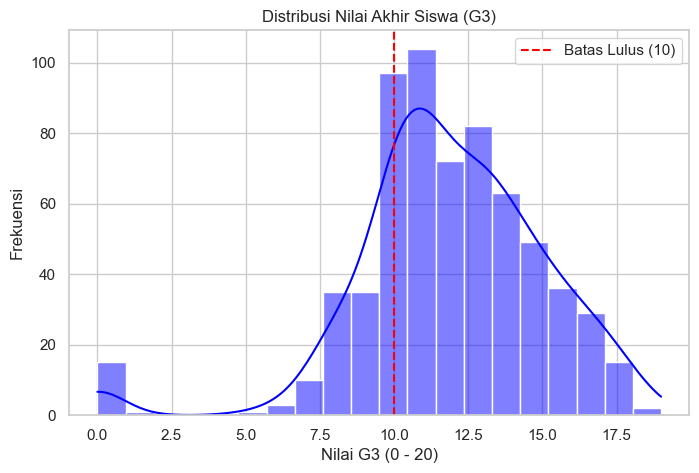

Jumlah siswa dengan nilai < 10 (Berisiko): 100 siswa (15.41%)


In [5]:
plt.figure(figsize=(8, 5))
sns.histplot(df['G3'], bins=20, kde=True, color='blue')
plt.title('Distribusi Nilai Akhir Siswa (G3)')
plt.xlabel('Nilai G3 (0 - 20)')
plt.ylabel('Frekuensi')

# Menambahkan garis batas lulus (Passing grade di Portugal biasanya 10)
plt.axvline(x=10, color='red', linestyle='--', label='Batas Lulus (10)')
plt.legend()
plt.show()

# Menghitung persentase siswa berisiko gagal
berisiko = df[df['G3'] < 10].shape[0]
total = df.shape[0]
print(f"Jumlah siswa dengan nilai < 10 (Berisiko): {berisiko} siswa ({berisiko/total*100:.2f}%)")

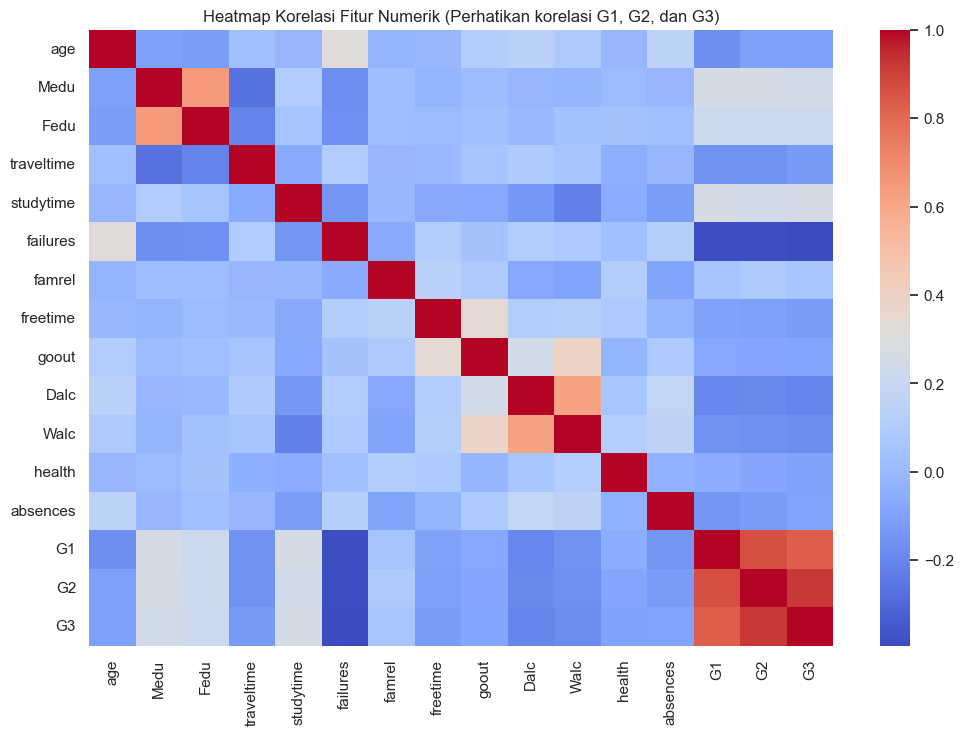

Korelasi fitur numerik terhadap G3:
G3            1.000000
G2            0.918548
G1            0.826387
studytime     0.249789
Medu          0.240151
Fedu          0.211800
famrel        0.063361
goout        -0.087641
absences     -0.091379
health       -0.098851
age          -0.106505
freetime     -0.122705
traveltime   -0.127173
Walc         -0.176619
Dalc         -0.204719
failures     -0.393316
Name: G3, dtype: float64


In [6]:
# Hanya mengambil kolom numerik untuk matriks korelasi
numeric_cols = df.select_dtypes(include=[np.number])

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_cols.corr(), annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap Korelasi Fitur Numerik (Perhatikan korelasi G1, G2, dan G3)')
plt.show()

# Menampilkan angka korelasi spesifik terhadap G3
print("Korelasi fitur numerik terhadap G3:")
print(numeric_cols.corr()['G3'].sort_values(ascending=False))

memprediksi kelulusan siswa menggunakan nilai ujian sebelumnya bukanlah sebuah penemuan (insight). Sistem analitik prediktif baru dikatakan memiliki nilai tambah tinggi (high business value) jika mampu menjawab: "Apakah kebiasaan minum alkohol di akhir pekan, ukuran keluarga, dan tingkat pendidikan ibu bisa memprediksi kegagalan siswa, bahkan sebelum ujian pertama dimulai?"

Dengan membuang G1 dan G2, kita memaksa model untuk mencari hidden pattern (pola tersembunyi) dari fitur-fitur sosial dan gaya hidup.

C:\Users\abdul khahar\AppData\Local\Temp\ipykernel_18028\2813867982.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Dalc', y='G3', data=df, ax=axes[0], palette='Set2')


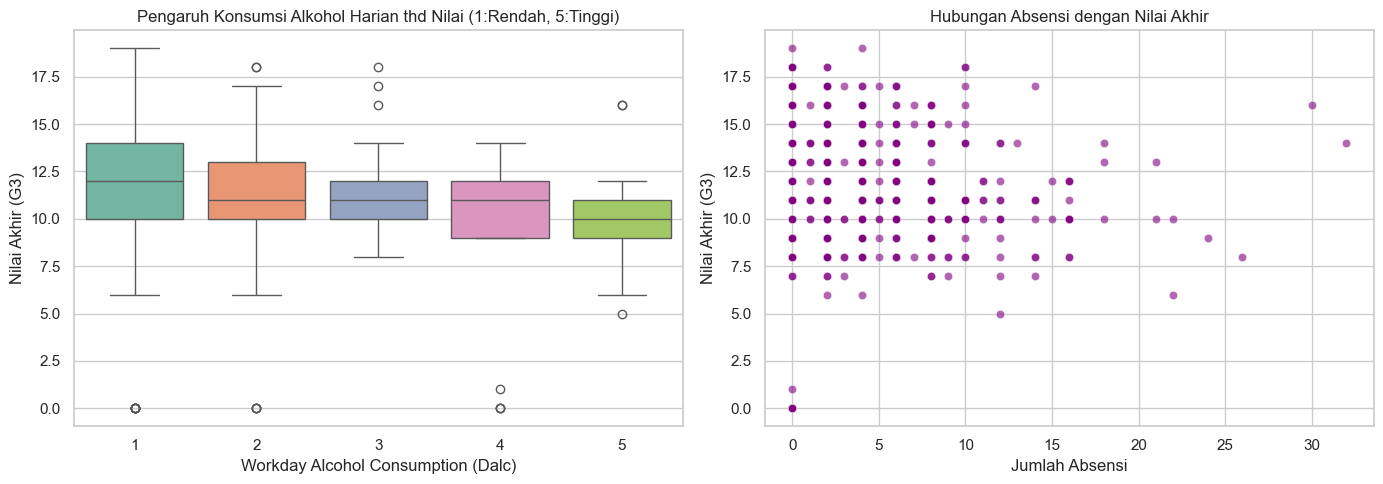

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Konsumsi alkohol harian vs Nilai akhir
sns.boxplot(x='Dalc', y='G3', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Pengaruh Konsumsi Alkohol Harian thd Nilai (1:Rendah, 5:Tinggi)')
axes[0].set_xlabel('Workday Alcohol Consumption (Dalc)')
axes[0].set_ylabel('Nilai Akhir (G3)')

# Absensi vs Nilai akhir (Scatter plot)
sns.scatterplot(x='absences', y='G3', data=df, ax=axes[1], alpha=0.6, color='purple')
axes[1].set_title('Hubungan Absensi dengan Nilai Akhir')
axes[1].set_xlabel('Jumlah Absensi')
axes[1].set_ylabel('Nilai Akhir (G3)')

plt.tight_layout()
plt.show()